# Exploring the past with OpenStreetMap: Snapshots in ohsome-planet
---

This tutorial shows you how to reconstruct past states of OpenStreetMap (OSM) data using the [ohsome-planet tool](https://github.com/GIScience/ohsome-planet) developed by [HeiGIT](https://heigit.org/). 
<br>

We will ground the tutorial in a practical use case: investigating housing growth in a small Dutch municipality and checking whether OpenStreetMap tells the same story as official government statistics.
Along the way, you will learn about what a **snapshot** is, how the **latest file** already represents one, and how to reconstruct snapshots at any past 
date from the **history file**.

(This tutorial is part of a broader series of **ohsome-planet schema deep dives**, designed to help you discover the structure behind the ohsome-planet tool.)

---

## The story behind this tutorial

While browsing the news, we came across this article from the Netherlands' national statistics office:

> **[Growth of housing stock slows for third year in a row](https://www.cbs.nl/en-gb/news/2026/05/growth-of-housing-stock-slows-for-third-year-in-a-row)**  
> *Centraal Bureau voor de Statistiek (CBS), 04/02/2026*

The article discusses how the Netherlands is building fewer new homes each year. A trend with real consequences for housing affordability. When housing supply grows more slowly than demand, prices rise and renting or buying becomes increasingly out of reach. 

Among all the statistics, one sentence caught our eyes:

> *"In relative terms, the municipality of Kapelle in Zeeland saw the largest increase in the number of homes in 2025. A total of 260 homes were built there, representing an expansion of 4.7 percent of Kapelle's housing stock."*

This immediately sparked a question: **can we see this growth reflected in OpenStreetMap data?**

To answer this question, we will work through for steps: 

1. Load the **latest ohsome-planet file** and map all buildings in Kapelle as they appear today --> not quite necessary for answering the question
2. Learn what a **snapshot** is and why the latest file already represents one
3. Switch to the **history file** to reconstruct snapshots at two specific dates: 1 January 2025 and 1 January 2026
4. Compare the results against CBS's figure of 260 new homes

Let's get set up

## Setup
---

### Import relevant libraries

In [43]:
#pip install pandas lonboard matplotlib duckdb geopandas requests

In [50]:
from pathlib import Path
import duckdb
from lonboard import Map, viz, PolygonLayer
from lonboard.colormap import apply_categorical_cmap 
from lonboard.basemap import MaplibreBasemap
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import requests
import ipywidgets as widgets 
from IPython.display import HTML
#import helper function needed for orchestration functions to work 
response = requests.get('https://raw.githubusercontent.com/Vanessa-dev-spatial/kappelle-osm-analysis/refs/heads/main/get_snapshot_helper_functions.py')
namespace = {}
exec(response.text, globals())
import warnings

### Load and install DuckDB extensions

In [51]:
# Enable spatial data support
duckdb.sql("INSTALL spatial; LOAD spatial")
# Enable reading files from URLs 
duckdb.sql('INSTALL httpfs; LOAD httpfs;')

### Suppress lonboard CRS warning

In [52]:
#Suppress UserWarnings from lonboard
warnings.simplefilter("ignore", category=UserWarning)

## Where is Kapelle?
---

Kapelle is a small municipality in the **Zeeland province** of the Netherlands.

In [53]:
# Get Kapelle municipal boundary
kapelle_aoi = duckdb.sql("""
SELECT * 
FROM st_read('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_NLD_2.json')
WHERE NAME_2 = 'Kapelle'
""")

#Sometimes retrieving boundaries from GADM is very slow. This slows down all other queries that mention kapelle_aoi.
#Alternative? PDOK 'https://service.pdok.nl/kadaster/brk-bestuurlijke-gebieden/atom/downloads/BestuurlijkeGebieden_2026.gpkg'

viz(kapelle_aoi, polygon_kwargs={'get_fill_color':[220, 235, 255, 20], 'get_line_color':[255, 255, 255, 180], 'line_width_min_pixels':1})

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

## Loading OSM data for Kapelle

To explore housing in Kapelle, we need OSM data for the area. We downloaded an `.osm.pbf` file for the Netherlands using **[GeoFabrik](https://osm-internal.download.geofabrik.de/)**. The GeoFabrik website allows users to download regional extracts containing OSM history data (**updated every day**). 
The Netherlands extract was then clipped to the Kapelle municipal boundary and later processed  with **ohsome-planet** to convert it into Parquet format.

<div style="background-color:#EAF4FB; border-left: 5px solid #2E86C1; padding: 15px 20px; border-radius: 4px; margin: 16px 0;">
  <h4 style="margin-top:0;">Ohsome-planet: File structure</h4>

Processing an `.osm.pbf` file with ohsome-planet tool produces the following directory structure:

  <pre style="background-color:#FFFFFF; border: 1px solid #AED6F1; border-radius: 4px; padding: 12px; font-size: 13px; line-height: 1.6;">
ohsome-planet/contributions/
├── history/
│   ├── relation-0-history-contribs.parquet
│   └── ...
└── latest/
    ├── node-0-latest-contribs.parquet
    ├── relation-0-latest-contribs.parquet
    ├── way-0-latest-contribs.parquet
    └── ...
  </pre>
There are two types of files:
- **latest/**: one snapshot of all active versions at the time of extraction, i.e. **all OSM features visible on the map at the time of extraction**
- **history/** : every _historical_ version of every OSM feature, ever edited

</div>

In [54]:
# Path to the ohsome-planet latest Parquet files
# The * wildcard loads all files in the latest/ directory at once

#Replace with this
#base_path = Path('') # add path to ohsome planet folder 
# kapelle_latest_path = base_path / 'ohsome-planet' / 'contributions' / 'latest' / '*.parquet'
# or base_path = Path(__name__).parent?

<div style="background-color:#EAF4FB; border-left: 5px solid #2E86C1; padding: 15px 20px; border-radius: 4px; margin: 16px 0;">
  <h4 style="margin-top:0;">The latest file</h4>

The latest file is a snapshot of all active versions at the time of extraction. In other words, it answers the question: _what does the OSM map look like right now?_

The exact moment of extraction depends on how the data was obtained:
- **BBike:** the snapshot time is approximately the moment you downloaded the file, before processing it with the ohsome-planet tool 
- **GeoFabrik:** the snapshot time is displayed on the download page under Commonly Used Formats (e.g. This file was last modified 10 hours ago and contains all OSM data up to `2026-03-01T21:21:30Z`) → remember to update when I will download new file

So when we say "let's map how Kapelle looks today", what we really mean is: _let's map Kapelle at the snapshot time of our extract_


</div>

With that in mind, let's load the latest file.

In [55]:
# Clip Geofabrik OSM data for Zeeland extract to exact municipal boundary of Kapelle
kapelle_latest_data = duckdb.sql(f"""
SELECT l.* 
FROM read_parquet('{kapelle_latest_path}') l 
JOIN kapelle_aoi a 
ON ST_Intersects(l.geometry, a.geom)
""") 

kapelle_latest_data.show(max_width=150, max_rows=10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────┬──────────────────────┬──────────────────────┬──────────┬───┬─────────┬───────────────┬──────────────────────┬───────────┬────────────┐
│ status  │      valid_from      │       valid_to       │ osm_type │ … │  refs   │ members_count │       members        │ countries │ build_time │
│ varchar │ timestamp with tim…  │ timestamp with tim…  │ varchar  │   │ int64[] │     int32     │ struct("type" varc…  │ varchar[] │   int64    │
├─────────┼──────────────────────┼──────────────────────┼──────────┼───┼─────────┼───────────────┼──────────────────────┼───────────┼────────────┤
│ latest  │ 2012-09-09 19:47:2…  │ 2222-01-01 00:00:0…  │ node     │ … │ NULL    │             0 │ NULL                 │ []        │      10301 │
│ latest  │ 2009-12-23 16:45:5…  │ 2222-01-01 00:00:0…  │ node     │ … │ NULL    │             0 │ NULL                 │ []        │       1400 │
│ latest  │ 2017-05-09 08:37:1…  │ 2222-01-01 00:00:0…  │ node     │ … │ NULL    │             0 │ NULL               

<div style="background-color:#EAF4FB; border-left: 5px solid #2E86C1; padding: 15px 20px; border-radius: 4px; margin: 16px 0;">
  <h4 style="margin-top:0;">What does one row represent?</h4>

Each row represents a single version of an OpenStreetMap (OSM) object. For every version, the dataset provides additional details, such as **how long that version was valid in OSM (valid_from, valid_to)** and the attributes that defined it (geometry, tags).

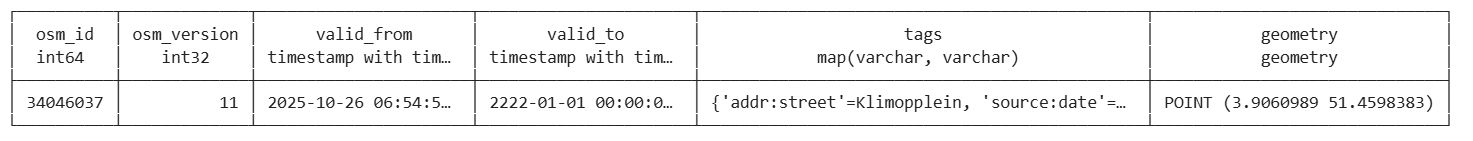

If valid_to is `2222-01-01 00:00:00`, it indicates that the version is still the active one at the time of extraction, meaning it is currently visible on the OpenStreetMap map.

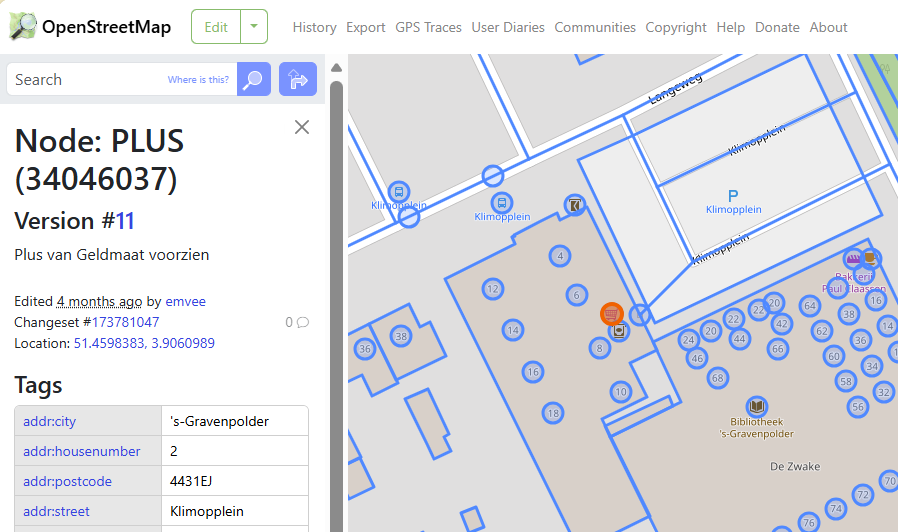
</div>

## Map all buildings in Kapelle today
---

As of now, the latest file contains all OSM features in the area, including nodes, ways, and relations. Since we are interested in **buildings only**, we need to filter the data accordingly. Before applying the filters, let’s review each one and understand what each one does.

> | Filter | What it does |
> |---|---|
> | `osm_type = 'way'` | Buildings in OSM are typically represented as **closed ways** (polygons). We exclude nodes for simplicity. |
> | `status != 'invalid'` | OSM element with invalid geometries |
> | `map_contains(tags, 'building')` | Keeps only OSM objects that have a `building` tag, regardless of its value. (Exception: building=no) |
> | `NOT map_contains_entry(tags, 'building', 'no')` | Excludes features tagged `building=no`, which explicitly indicate that something is *not* a building. |

In [56]:
# Filter dataset to include buildings only and visualize
kapelle_latest_buildings = duckdb.sql(f"""
SELECT * 
FROM kapelle_latest_data
WHERE 1=1
AND osm_type = 'way'
AND status != 'invalid'
AND map_contains(tags, 'building')
AND NOT map_contains_entry(tags, 'building', 'no')
""") 


viz(kapelle_latest_buildings, 
    polygon_kwargs={'get_fill_color':[255, 200, 50, 220], 'get_line_color':[180, 120, 60, 230], 'line_width_min_pixels': 0.5}, 
    map_kwargs={'basemap': MaplibreBasemap(style='https://basemaps.cartocdn.com/gl/voyager-gl-style/style.json'), 'view_state':{'longitude': 3.96, 'latitude': 51.49, 'zoom': 11}})

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

The map above shows every building in Kapelle as of [add].

## Identifying residential buildings

---

But the CBS statement is not about buildings in general, it is about **homes**. 

> *"In relative terms, the municipality of Kapelle in Zeeland saw the largest increase in the 
> number of homes in 2025. A total of 260 homes were built there, representing an expansion of 
> 4.7 percent of Kapelle's housing stock."*

This distinction matters for housing affordability. Affordability is not about how many buildings exist in total, but about the number of homes available for people to live in. A municipality may construct numerous commercial or industrial buildings without adding a single dwelling to its housing supply. What truly matters for housing affordability is the growth of residential units.

$$\text{Total Buildings} = \text{Residential Buildings} + \text{Non-Residential Buildings}$$

Before we go any further, it is worth being precise about what is being counted, and what is not.

**First: CBS is not counting all buildings.**

When CBS says that **260 new homes were built in Kapelle in 2025**, it is not counting all buildings, rather it is counting **residential buildings only**. To determine which buildings serve a residential function, CBS relies on the **BAG (Basisregistratie Adressen en Gebouwen)**, the Dutch national registry of all addresses and buildings, maintained by [Kadaster](https://www.kadaster.nl/). 

**Second: CBS is not counting buildings as they are built throughout the year or an average**

Although this is not stated explicitly in the article, it is essential for understanding how the reported figure is calculated. CBS does not track each new home the moment it is completed, nor does it compute a yearly average.Instead, CBS takes two **snapshots** of the BAG: one 
on **1 January 2025** and one on **1 January 2026** and counts the difference in the number of residential units between these two fixed points in time.

In other words, the CBS figure is the result of:

$$\text{260 new homes} = \text{Residential buildings (1 Jan 2026)} - \text{Residential buildings (1 Jan 2025)}$$

To check this figure using OSM data, we need to do exactly the same thing. We need to take two snapshots 
of OSM, one at each date, count the residential buildings in each, and compare. Achieving this requires understanding how to take a snapshot from OSM data.

## Reconstructing Snapshots from the history file

In [ ]:
# Path to the ohsome-planet history Parquet files
# The * wildcard loads all files in the latest/ directory at once

#Replace with this
#base_path = Path('') # add path to ohsome planet folder 
# kapelle_history_path = base_path / 'ohsome-planet' / 'contributions' / '**' / '*.parquet'  --include both latest and history
# or base_path = Path(__name__).parent

In [ ]:
kapelle_history_data = duckdb.sql(f"""
SELECT h.* 
FROM read_parquet('{kapelle_history_path}') h
JOIN kapelle_aoi a 
ON ST_Intersects(h.geometry, a.geom)
""")

kapelle_history_data.show(max_width=150, max_rows=10)

Now we get to the heart of this tutorial.

To verify CBS's claim, we need to **compare the number of residential buildings on 1 January 2025 with the number on 1 January 2026**. If OSM data reflects the same trend, we should see a difference of around 260 buildings.

The latest file gives us a snapshot of *right now*. But to compare two points in the past, we need to work with the **history file**.


<div style="background-color:#EAF4FB; border-left: 5px solid #2E86C1; padding: 15px 20px; border-radius: 4px; margin: 16px 0;">

  <h3>Deriving snapshots from the history file</h3>

  <p>ohsome-planet produces <strong>two types of files</strong>:</p>

  <table style="width:100%; border-collapse: collapse; margin: 10px 0; background-color:#FFFFFF;">
    <thead>
      <tr style="background-color:#D6EAF8;">
        <th style="text-align:left; padding: 8px 12px; border: 1px solid #AED6F1;">File type</th>
        <th style="text-align:left; padding: 8px 12px; border: 1px solid #AED6F1;">What it contains</th>
        <th style="text-align:left; padding: 8px 12px; border: 1px solid #AED6F1;">Use it when...</th>
      </tr>
    </thead>
    <tbody>
      <tr style="background-color:#FFFFFF;">
        <td style="padding: 8px 12px; border: 1px solid #AED6F1;"><strong>Latest</strong></td>
        <td style="padding: 8px 12px; border: 1px solid #AED6F1;">One snapshot of all currently visible OSM features</td>
        <td style="padding: 8px 12px; border: 1px solid #AED6F1;">You want to know what exists <em>now</em></td>
      </tr>
      <tr style="background-color:#FFFFFF;">
        <td style="padding: 8px 12px; border: 1px solid #AED6F1;"><strong>History</strong></td>
        <td style="padding: 8px 12px; border: 1px solid #AED6F1;">Every <i>historical</i> version of every OSM feature, ever</td>
        <td style="padding: 8px 12px; border: 1px solid #AED6F1;">You want to reconstruct what existed at <em>any point in time</em></td>
      </tr>
    </tbody>
  </table>

  <p>The concept of a <strong>snapshot</strong> is the same in both cases:</p>

  <blockquote style="border-left: 3px solid #2E86C1; margin: 10px 0; padding: 6px 14px; color: #000000;">
    <em>A snapshot is the set of all OSM features that were visible on the map at a specific moment in time.</em>
  </blockquote>

  <ul>
    <li>The <strong>latest file</strong> <em>is already a snapshot.</em>It is just pre-computed for you at the time of extraction.</li>
    <li>The <strong>history file</strong> lets you <em>derive</em> a snapshot at any arbitrary timestamp by asking: <em>"which features were active on date X?"</em></li>
  </ul>

  <p>Both answer the same question, they just do it at different times.</p>

Extracting snapshots from the history file essentially requires **selecting versions that were created before the desired snapshot date, while making sure to remove versions that were deleted before the desired snapshot date**. In SQL language, this translates to

> SELECT * <br>
> FROM read_parquet('/ohsome_planet/contributions/**/*.parquet') -- latest > and history <br>
> WHERE 1=1 <br> 
> AND status != 'deleted' <br>
> **AND valid_from <= '{snapshot_date}' <br>
> AND valid_to > '{snapshot_date}'** <br>

</div>

<div style="background-color:#EAF4FB; border-left: 5px solid #2E86C1; padding: 15px 20px; border-radius: 4px; margin: 16px 0;">
<h4>Deleted versions</h4>

In the ohsome-planet history file, when an OSM object is deleted, a new row (i.e. a new version) will be created with status = ‘deleted’, valid_from equal to the date of deletion and valid_to = `‘2222-01-01 00:00:00’`. → not all actually (how to deal with those?) 

It is important to remove versions with status = ‘deleted’ when extracting snapshots because there is the risk of including them if their deletion occurred before the desired snapshot date. 

> SELECT * <br>
> FROM read_parquet('/ohsome_planet/contributions/**/*.parquet') --> includes latest and history files <br>
> WHERE 1=1 <br> 
> **AND status != 'deleted'** <br>
> AND valid_from <= '{snapshot_date}' <br>
> AND valid_to > '{snapshot_date}' <br>

This will happen because valid_from will be <= {snapshot date} and valid_to > {snapshot_date}. **Valid_to will always be greater than the snapshot date because it will contain a date far off in the future (`‘2222-01-01 00:00:00’`)**. 

</div> 

Regardless of the snapshot date chosen, the logic stays the same. To avoid having to rewrite the same query over and over again, here two functions that abstract the logic: 

- **`get_snapshot(timestamp)`**: returns all individual OSM features that were visible at `timestamp`
- **`get_snapshot_summary(timestamp)`**: returns aggregated statistics (counts, lengths, areas) at `timestamp`, without returning individual features

Let's use both to answer our question.

In [ ]:
def get_snapshot(osm_history_data, date, mode=None, where_clauses=None):
    """
    Retrieve OSM data at specific point in time (snapshot)
    
    Parameters:
        osm_history_data: parquet file path 
        date: snapshot date string
        mode: None, 'start_of', or 'end_of'
        where_clauses: list of additional SQL WHERE conditions

    Returns:
    snapshot_date (str): string specifying snapshot of OSM data 
    data (DuckDB PyRelation): OSM data as of snapshot_date 
    """
    
    # Validate and convert date string
    dt, input_granularity = _check_validity_input_time_parameters(date)

    if mode == 'start_of':
        dt = _normalize_start(dt, input_granularity)
    elif mode == 'end_of':
        dt = _normalize_end(dt, input_granularity)
    # Normalized already to start_of in _check_validity_input_time_parameters, unless precise input provided
    elif mode is None:
        dt = _normalize_start(dt, input_granularity)
    else:
        raise ValueError(f"Invalid mode. Expected None, 'start_of' or 'end_of', got '{mode}'")

    # Format datetime object to string for SQL
    snapshot_date = dt.strftime('%Y-%m-%d %H:%M:%S')

    # Dynamically build FROM clause based on input source type 

    input_source = _check_input_source(osm_history_data)

    # Dynamically build SQL based on custom WHERE filters
    if where_clauses is None:
        where_clauses = ''
    else: 
        where_clauses = "\n AND " + "\n AND ".join(where_clauses)
        
    query = f"""
        SELECT * 
        FROM {input_source}
        WHERE 1=1
        AND valid_from <= '{snapshot_date}'
        AND valid_to > '{snapshot_date}'
        AND status != 'deleted'
        {where_clauses}
        """
    
    print(f"Snapshot of OSM history data as of: {snapshot_date}")
    return snapshot_date, duckdb.sql(query)

In [ ]:
def get_snapshot_summary(osm_history_data, date, group_by=None, metrics=['count'], mode=None, where_clauses=None):
    """
    Get aggregated statistics at a point in time (not individual features)
    
    Parameters:
        osm_history_data: parquet file path 
        date: snapshot date string
        group_by: column(s) to group by e.g. 'osm_type' or ['osm_type', 'status'] #support more complex filtering
        metrics: list of metrics to compute:
            - 'count': number of features
            - 'total_length': sum of lengths
            - 'total_area': sum of areas
            - 'avg_tags': average number of tags
        mode: None, 'start_of', or 'end_of'
        where_clauses: list of additional SQL WHERE conditions

    Returns:
    snapshot_date (str): string specifying snapshot of OSM data 
    data (DuckDB PyRelation): aggregate statistics derived from snapshot data 
    """
    
    # Validate and convert date string
    dt, input_granularity = _check_validity_input_time_parameters(date)
    if mode == 'start_of':
        dt = _normalize_start(dt, input_granularity)
    elif mode == 'end_of':
        dt = _normalize_end(dt, input_granularity)
    elif mode is None:
        dt = _normalize_start(dt, input_granularity)
    else:
        raise ValueError(f"Invalid mode. Expected None, 'start_of' or 'end_of', got '{mode}'")

    snapshot_date = dt.strftime('%Y-%m-%d %H:%M:%S')

    # Dynamically build group_by clause
    if isinstance(group_by, list):
        group_by_clause = ", ".join(group_by)
    else:
        group_by_clause = group_by

    # Dyncamically build metrics
    metric_clauses = []
    for metric in metrics:
        if metric == 'count':
            metric_clauses.append("COUNT(*) as count")
        elif metric == 'total_length':
            metric_clauses.append("SUM(ST_Length(geometry)) as total_length")
        elif metric == 'total_area':
            metric_clauses.append("SUM(ST_Area(geometry)) as total_area")
        elif metric == 'avg_tags':
            metric_clauses.append("AVG(cardinality(tags)) as avg_tags")
        else:
            raise ValueError(f"Unknown metric '{metric}'. Expected: count, total_length, total_area, avg_tags")
    
    select_metrics = ",\n ".join(metric_clauses)

    
    # Dynamically build SQL WHERE clauses 
    if where_clauses is None:
        where_clauses = ''
    else:
        where_clauses = "\n AND " + "\n AND ".join(where_clauses)
        
    query = f"""
        SELECT 
        {group_by_clause},
        {select_metrics}
        FROM read_parquet('{osm_history_data}')
        WHERE valid_from <= '{snapshot_date}'
        AND valid_to > '{snapshot_date}'
        AND status != 'deleted'
        {where_clauses}
        GROUP BY {group_by_clause}
        ORDER BY count DESC
    """

    print(f"Snapshot summary as of: {snapshot_date}")
    return snapshot_date, duckdb.sql(query)

### How to identify residential buildings in OSM:

First, how can residential buildings be identified in OSM?

In OpenStreetMap buildings with the following tags are considered as residential buildings [link]((https://wiki.openstreetmap.org/wiki/Key:building#Accommodation):

In [ ]:
where_clauses = [
    "osm_type = 'way'",
    "status != 'deleted'",
    "status != 'invalid'", 
    "( \
     map_contains_entry(tags, 'building', 'apartments') \
     OR map_contains_entry(tags, 'building', 'barracks') \
     OR map_contains_entry(tags, 'building', 'bungalow') \
     OR map_contains_entry(tags, 'building', 'cabin') \
     OR map_contains_entry(tags, 'building', 'detached') \
     OR map_contains_entry(tags, 'building', 'annexe') \
     OR map_contains_entry(tags, 'building', 'dormitory') \
     OR map_contains_entry(tags, 'building', 'farm') \
     OR map_contains_entry(tags, 'building', 'ger') \
     OR map_contains_entry(tags, 'building', 'hotel') \
     OR map_contains_entry(tags, 'building', 'house') \
     OR map_contains_entry(tags, 'building', 'houseboat') \
     OR map_contains_entry(tags, 'building', 'residential') \
     OR map_contains_entry(tags, 'building', 'semidetached_house') \
     OR map_contains_entry(tags, 'building', 'static_caravan') \
     OR map_contains_entry(tags, 'building', 'stilt_house') \
     OR map_contains_entry(tags, 'building', 'terrace') \
     OR map_contains_entry(tags, 'building', 'tree_house') \
     OR map_contains_entry(tags, 'building', 'trullo') \
    )"
]   

Even with the mismatch in definition regarding what counts as a building being residential, **will OpenStreetMap data still reflect the positive trend CBS identified in housing supply for the city of Kappelle?**

- Will the difference be considerable?
- If yes, is the difference a result of definition mismatch?
- If no, even with different definitions, CBS's statement is solid

In [57]:
snapshot_date, kapelle_buildings_2025_01_01 = get_snapshot(kapelle_history_data, '2025-01-01', where_clauses=where_clauses)
snapshot_date, kapelle_buildings_2026_01_01 = get_snapshot(kapelle_history_data, '2026-01-01', where_clauses=where_clauses)

Snapshot of OSM history data as of: 2025-01-01 00:00:00
Snapshot of OSM history data as of: 2026-01-01 00:00:00


In [58]:
# Create map layers for each snapshot
kapelle_buildings_layer_2025 = PolygonLayer.from_duckdb(kapelle_buildings_2025_01_01.filter("geometry_type != 'LineString'"))
kapelle_buildings_layer_2026 = PolygonLayer.from_duckdb(kapelle_buildings_2026_01_01.filter("geometry_type != 'LineString'"))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [59]:
kapelle_aoi_layer = PolygonLayer.from_duckdb(
    kapelle_aoi,
    get_fill_color=[220, 235, 255, 20],
    get_line_color=[255, 255, 255, 180],
    line_width_min_pixels=1,
    pickable=False
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
layers = {
    "2025": kapelle_buildings_layer_2025,
    "2026": kapelle_buildings_layer_2026
}

m = {}

for name, layer in layers.items():
    layer.get_fill_color = [255, 200, 50, 220]
    layer.get_line_color = [180, 120, 60, 230]
    layer.line_width_min_pixels = 0.5
    layer.opacity = 0.9
    layer.before_id ="watername_ocean"
    m[name] = Map(layers=[kapelle_aoi_layer, layer], basemap=MaplibreBasemap(mode='interleaved', style='https://basemaps.cartocdn.com/gl/dark-matter-gl-style/style.json'), view_state={
    'longitude': 3.95,
    'latitude': 51.48,
    'zoom': 11
    })

In [ ]:
grid = widgets.GridBox(
    [m['2025'], m['2026']],
    layout=widgets.Layout(
        grid_template_columns="repeat(2, 600px)",
        grid_gap="10px"
    )
)

display(
    HTML("<h2 style='font-family: sans-serif; text-align: center;'>Municipality Kapelle: buildings 2025 → 2026</h2>"),
    grid
)

## Does OSM reflect the CBS's finding?

Now we can use `get_snapshot_summary()` to count residential buildings at both points in time, and see if the trend CBS identified is visible in OSM data.

In [ ]:
print(f"Residentail buildings 2025: {kapelle_buildings_2025_01_01.count('*').fetchone()[0]:,}")
print(f"Residential buildings 2026: {kapelle_buildings_2026_01_01.count('*').fetchone()[0]:,}")

In [ ]:
#Maybe not necessary since no grouping is performed. COUNT all
#snapshot_date, results_2025 = get_snapshot_summary(kapelle_history_data, date='2025-01-01', metrics=['count'])
#snpahot_date, results_2026 = get_snapshot_summary(kapelle_history_data, date='2026-01-01', metrics=['count'])

### Visualize newly constructured buildings

In [ ]:
# Which OSM ids are present in 2026 that were not present in 2025 
newly_added_homes = duckdb.sql("""
SELECT *
FROM kapelle_buildings_2026_01_01 n
WHERE NOT EXISTS (SELECT 1 
                FROM kapelle_buildings_2025_01_01 o
                WHERE n.osm_id = o.osm_id
                )
""")

newly_added_homes.show(max_width=100, max_rows=10)

In [ ]:
newly_added_layer = PolygonLayer.from_duckdb(
    newly_added_homes,
    get_fill_color=[50, 205, 50, 220],
    get_line_color=[0, 128, 0, 255],
    line_width_min_pixels=1,
    pickable=True
)

In [ ]:
Map(layers=[kapelle_aoi_layer, kapelle_buildings_layer_2025, newly_added_layer], basemap=MaplibreBasemap(style='https://basemaps.cartocdn.com/gl/voyager-nolabels-gl-style/style.json'), view_state={
    'longitude': 3.95,
    'latitude': 51.48,
    'zoom': 11
    })

## Conclusion
---

In this tutorial, we explored **how to reconstruct past states of OSM data using ohsome-planet** by taking snapshots of the history file.

Applying this method to Kapelle, we reconstructed snapshots for 1 January 2025 and 1 January 2026 to track residential buildings. Comparing our results with CBS’s official statistics of 260 new homes, we found that **OSM data closely mirrors this trend**, identifying 255 new homes, showing a similar increase in housing stock.

### 🔜 Next in this tutorial series
---